In [ ]:
pip install pandas numpy scikit-learn tensorflow mealpy

In [ ]:
pip install Mealpy

INFO:mealpy.swarm_based.ABC.OriginalABC:OriginalABC(epoch=10, pop_size=10, n_limits=25)


1. Veri yükleniyor...
2. ABC Optimizasyonu başlıyor... (Bu işlem birkaç dakika sürebilir, arılar çalışıyor!)


INFO:mealpy.swarm_based.ABC.OriginalABC:>>>Problem: P, Epoch: 1, Current best: 0.0012769605964422226, Global best: 0.0012769605964422226, Runtime: 62.18947 seconds
INFO:mealpy.swarm_based.ABC.OriginalABC:>>>Problem: P, Epoch: 2, Current best: 0.00115362333599478, Global best: 0.00115362333599478, Runtime: 59.92867 seconds
INFO:mealpy.swarm_based.ABC.OriginalABC:>>>Problem: P, Epoch: 3, Current best: 0.00115362333599478, Global best: 0.00115362333599478, Runtime: 58.80155 seconds
INFO:mealpy.swarm_based.ABC.OriginalABC:>>>Problem: P, Epoch: 4, Current best: 0.0010665756417438388, Global best: 0.0010665756417438388, Runtime: 61.14904 seconds
INFO:mealpy.swarm_based.ABC.OriginalABC:>>>Problem: P, Epoch: 5, Current best: 0.0010665756417438388, Global best: 0.0010665756417438388, Runtime: 72.80997 seconds
INFO:mealpy.swarm_based.ABC.OriginalABC:>>>Problem: P, Epoch: 6, Current best: 0.0010665756417438388, Global best: 0.0010665756417438388, Runtime: 62.50218 seconds
INFO:mealpy.swarm_based.


OPTİMİZASYON TAMAMLANDI!
ABC'nin Bulduğu En İyi Nöron Sayısı: 43
ABC'nin Bulduğu En İyi Öğrenme Oranı: 0.03706
Ulaşılan En Düşük Hata (MSE): 0.00107

3. Nihai ABC-LSTM Modeli en iyi parametrelerle eğitiliyor...
Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.2633
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0433 
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0212 
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0169 
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0155 
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0178 
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0154 
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0140 
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0126 
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0140 
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0120 
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0107 
Epoch 13/50
8/8 ━━

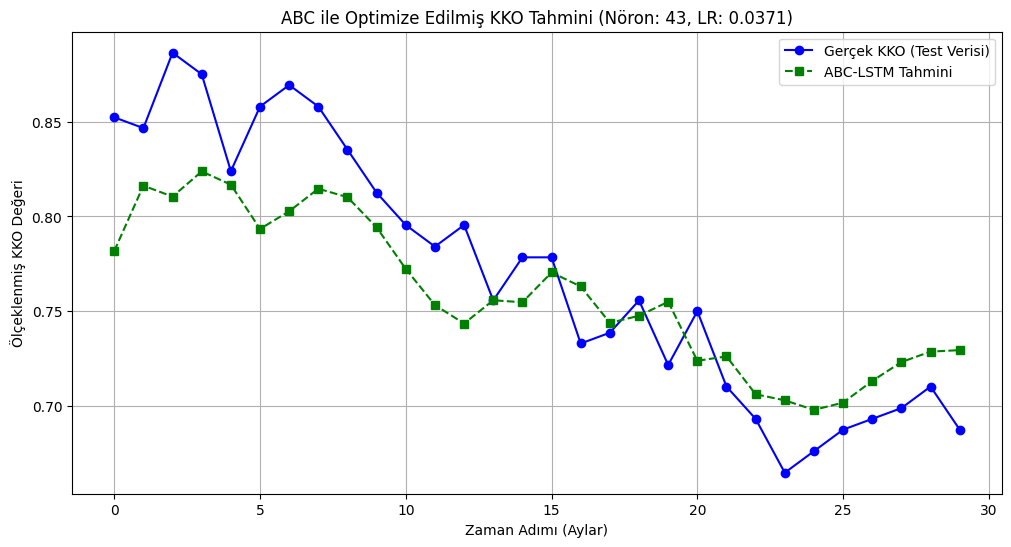

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from mealpy.swarm_based.ABC import OriginalABC
from mealpy import FloatVar, IntegerVar  # YENİ EKLENEN KISIM
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# 1. VERİ YÜKLEME VE HAZIRLAMA
# ==========================================
print("1. Veri yükleniyor...")
df = pd.read_csv("veri.csv")
data = df[['KKO_MA', 'RKGA_MA']].values # Hedefimiz KKO_MA'yı tahmin etmek. Girdi olarak hem KKO_MA hem de RKGA_MA kullanacağız.
# VERİ ÖLÇEKLENDİRME Yapay sinir ağları büyük sayılarla çalışmayı sevmez, bu yüzden veriyi [0, 1] aralığına çekiyoruz.
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)
# ZAMAN SERİSİ PENCERELERİ OLUŞTUR:Modelin geçmiş kaç aya bakarak geleceği tahmin edeceğini belirliyoruz. (Örn: 3 ay)
look_back = 3

X, Y = [], []
for i in range(len(scaled_data) - look_back):
    X.append(scaled_data[i:(i + look_back), :]) # X: Girdi (Son 3 ayın KKO ve RKGA verileri)
    Y.append(scaled_data[i + look_back, 0]) # Y: Çıktı (Tahmin edilecek KKO değeri, yani sütun indeksi 0)

X = np.array(X)
Y = np.array(Y)

#veriyi bölme (%80 eğitim %20 test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
Y_train, Y_test = Y[:train_size], Y[train_size:]

# ==========================================
# 2. ABC İÇİN UYGUNLUK (FITNESS) FONKSİYONU
# ==========================================
def lstm_fitness(solution):
    units = int(solution[0]) #Arının denediği LSTM nöron sayısı
    lr = solution[1] #Arının denediği öğrenme oranı
#LSTM modeli
    model = Sequential()
    model.add(LSTM(units=units, activation='tanh', input_shape=(look_back, 2)))
    model.add(Dense(units=1))

    optimizer = Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mean_squared_error')

    model.fit(X_train, Y_train, epochs=15, batch_size=16, verbose=0)
    loss = model.evaluate(X_test, Y_test, verbose=0)
    return loss

# ==========================================
# 3. ABC ALGORİTMASINI ÇALIŞTIRMA (GÜNCELLENDİ)
# ==========================================
print("2. ABC Optimizasyonu başlıyor... (Bu işlem birkaç dakika sürebilir, arılar çalışıyor!)")

# YENİ MEALPY SÜRÜMÜ İÇİN SINIRLAR (BOUNDS)
bounds = [
    IntegerVar(lb=10, ub=100, name="units"),  # Nöron sayısı tam sayı olmalı
    FloatVar(lb=0.001, ub=0.05, name="lr")    # Öğrenme oranı ondalıklı olmalı
]

problem_dict = {
    "obj_func": lstm_fitness, # fit_func yerine obj_func oldu
    "bounds": bounds,         # lb ve ub yerine bounds kullanılıyor
    "minmax": "min",
}

model_abc = OriginalABC(epoch=10, pop_size=10)
g_best = model_abc.solve(problem_dict) # Yeni sürüm g_best adında bir obje döndürür

# En iyi sonuçları obje içinden çekiyoruz
best_units = int(g_best.solution[0])
best_lr = g_best.solution[1]
best_fitness = g_best.target.fitness

print("\n" + "="*40)
print("OPTİMİZASYON TAMAMLANDI!")
print(f"ABC'nin Bulduğu En İyi Nöron Sayısı: {best_units}")
print(f"ABC'nin Bulduğu En İyi Öğrenme Oranı: {best_lr:.5f}")
print(f"Ulaşılan En Düşük Hata (MSE): {best_fitness:.5f}")
print("="*40)

# ==========================================
# 4. NİHAİ MODELİ (OPTİMİZE EDİLMİŞ) EĞİTME VE ÇİZİM
# ==========================================
print("\n3. Nihai ABC-LSTM Modeli en iyi parametrelerle eğitiliyor...")
final_model = Sequential()
final_model.add(LSTM(units=best_units, activation='tanh', input_shape=(look_back, 2)))
final_model.add(Dense(units=1))

final_optimizer = Adam(learning_rate=best_lr)
final_model.compile(optimizer=final_optimizer, loss='mean_squared_error')

final_model.fit(X_train, Y_train, epochs=50, batch_size=16, verbose=1)

predictions = final_model.predict(X_test)

plt.figure(figsize=(12, 6))
plt.plot(Y_test, color='blue', label='Gerçek KKO (Test Verisi)', marker='o')
plt.plot(predictions, color='green', label='ABC-LSTM Tahmini', linestyle='dashed', marker='s')
plt.title(f'ABC ile Optimize Edilmiş KKO Tahmini (Nöron: {best_units}, LR: {best_lr:.4f})')
plt.xlabel('Zaman Adımı (Aylar)')
plt.ylabel('Ölçeklenmiş KKO Değeri')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error


#  ABC-LSTM için Hata Metriklerinin Hesaplanması
mse_abc = mean_squared_error(Y_test, predictions)
rmse_abc = np.sqrt(mse_abc)
mae_abc = mean_absolute_error(Y_test, predictions)

print(mse_abc)
print(rmse_abc)
print(mae_abc)

0.0013014455697200852
0.03607555363012583
0.030054002097158725
